# tuning — DQN/DDQN learning-rate sensitivity across every tuning environment

Combines the 8 individual `*_tuning` experiments (Acrobot, Cartpole, Catch,
MountainCar, and Pinball's box/easy/empty/medium settings) into one experiment.
Each environment sweeps `LR` for DQN and DDQN (10 seeds each) against a 10-seed
Random baseline, following that environment's own tuning recipe (see `config.py`).
For every environment: (1) a sensitivity curve of the return- or reward-based
metric against learning rate, and (2) a learning curve comparing each agent's
best LR against Random. Catch is a continuing task with no episode to derive a
return from, so it plots the reward stream directly: average lifetime reward
for sensitivity, and an EMA (beta=0.99) of reward for the learning curve.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from experiment import load_curves, load_runs
from experiment.plotting import (
    average_lifetime_reward_stack,
    ema_reward_grids_for,
    plot_mean_ci,
    seed_grids_for,
    style,
    weighted_lifetime_return_stack,
)

HERE = Path.cwd()
RESULTS = HERE / "results" if (HERE / "results").exists() else Path("experiments/tuning/results")
PLOTS_DIR = RESULTS.parent / "plots"
PLOTS_DIR.mkdir(exist_ok=True)


def grid_for(component_db, n=500):
    """A shared [0, T] timestep grid from any run's curve length (T = TOTAL_TIMESTEPS)."""
    df = load_runs(component_db, write_csv=False)
    T = len(load_curves(component_db, df["run_id"][0])["reward"])
    return np.linspace(0, T, n)


ENVS = [
    dict(key="cartpole", title="Cartpole",
         lr_sweep=[4.0 ** -i for i in (2, 3, 4, 5, 6, 7, 8)],
         metric="return", ylim=(0, 500)),
    dict(key="acrobot", title="Acrobot",
         lr_sweep=[4.0 ** -i for i in (2, 3, 4, 5, 6, 7, 8)],
         metric="return", ylim=(-500, 0)),
    dict(key="mountaincar", title="MountainCar",
         lr_sweep=[4.0 ** -i for i in (2, 3, 4, 5, 6, 7)],
         metric="return", ylim=(-1000, 0)),
    dict(key="catch", title="Catch",
         lr_sweep=[4.0 ** -i for i in (2, 3, 4, 5, 6, 7)],
         metric="reward", ylim=None),
    dict(key="pinball_box", title="Pinball (Box)",
         lr_sweep=[4.0 ** -i for i in (2, 3, 4, 5, 6, 7)],
         metric="return", ylim=(-1000, 0)),
    dict(key="pinball_easy", title="Pinball (Easy)",
         lr_sweep=[4.0 ** -i for i in (2, 3, 4, 5, 6, 7)],
         metric="return", ylim=(-1000, 0)),
    dict(key="pinball_empty", title="Pinball (Empty)",
         lr_sweep=[4.0 ** -i for i in (2, 3, 4, 5, 6, 7)],
         metric="return", ylim=(-1000, 0)),
    dict(key="pinball_medium", title="Pinball (Medium)",
         lr_sweep=[4.0 ** -i for i in (2, 3, 4, 5, 6, 7)],
         metric="return", ylim=(-1000, 0)),
]

In [2]:
def analyze(key, title, lr_sweep, metric, ylim):
    """Sensitivity + best-LR learning-curve plots for one environment.

    Saves ``<key>_sensitivity.pdf`` and ``<key>_learning_curve.pdf`` to
    ``PLOTS_DIR``. Returns each agent's best LR (used to pick which LR's curve
    to plot, not shown in the plots themselves).
    """
    is_return = metric == "return"
    stack_fn = weighted_lifetime_return_stack if is_return else average_lifetime_reward_stack
    curve_fn = seed_grids_for if is_return else ema_reward_grids_for
    sens_ylabel = "Weighted\nlifetime\nreturn" if is_return else "Average\nlifetime\nreward"
    curve_ylabel = "Return" if is_return else "Reward\n(EMA)"
    plot_title = f"{title} (10 seeds, 95% CI)"

    AGENTS = [("DQN", "tab:blue", "dqn"), ("DDQN", "tab:green", "ddqn")]
    fig, ax = plt.subplots(figsize=(9, 6))   # 2:3 height:width
    best_lr = {}
    for label, color, name in AGENTS:
        comp_db = RESULTS / f"{name}_{key}.db"
        stack = stack_fn(comp_db, "AGENT_HYPERS.LR", lr_sweep)
        mean = plot_mean_ci(ax, np.array(lr_sweep), stack, label, color)
        best_lr[name] = lr_sweep[int(np.nanargmax(mean))]

    ax.set_xscale("log")
    ax.set_title(plot_title)
    ax.legend(loc="best", frameon=False)
    style(ax, xlabel="Learning rate (log scale)", ylabel=sens_ylabel)
    fig.tight_layout()
    plt.show()

    SERIES = [
        ("Random", "tab:red", "random", None),
        ("DQN", "tab:blue", "dqn", best_lr["dqn"]),
        ("DDQN", "tab:green", "ddqn", best_lr["ddqn"]),
    ]
    fig2, ax2 = plt.subplots(figsize=(9, 6))   # 2:3 height:width
    for label, color, name, lr in SERIES:
        comp_db = RESULTS / f"{name}_{key}.db"
        grid = grid_for(comp_db)
        run_ids = None
        if lr is not None:
            df = load_runs(comp_db, write_csv=False)
            run_ids = df.filter(df["AGENT_HYPERS.LR"] == lr)["run_id"].to_list()
        stack = curve_fn(comp_db, grid, run_ids=run_ids)
        plot_mean_ci(ax2, grid, stack, label, color)

    ax2.set_title(plot_title)
    ax2.legend(loc="lower right", frameon=False)
    style(ax2, ylim=ylim, ylabel=curve_ylabel)
    fig2.tight_layout()
    plt.show()

    fig.savefig(PLOTS_DIR / f"{key}_sensitivity.pdf", bbox_inches="tight")
    fig2.savefig(PLOTS_DIR / f"{key}_learning_curve.pdf", bbox_inches="tight")
    print(f"[{key}] best LR: {best_lr}")
    return best_lr

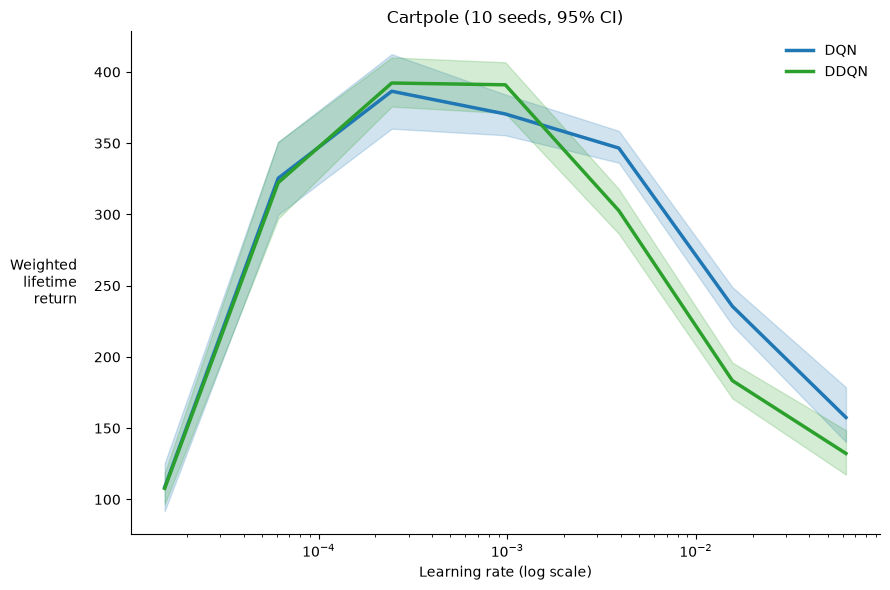

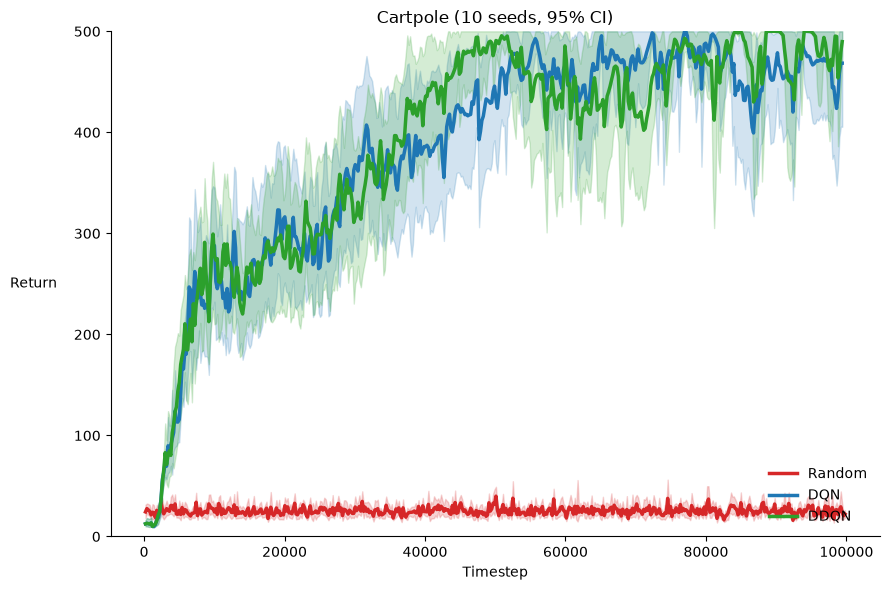

[cartpole] best LR: {'dqn': 0.000244140625, 'ddqn': 0.000244140625}


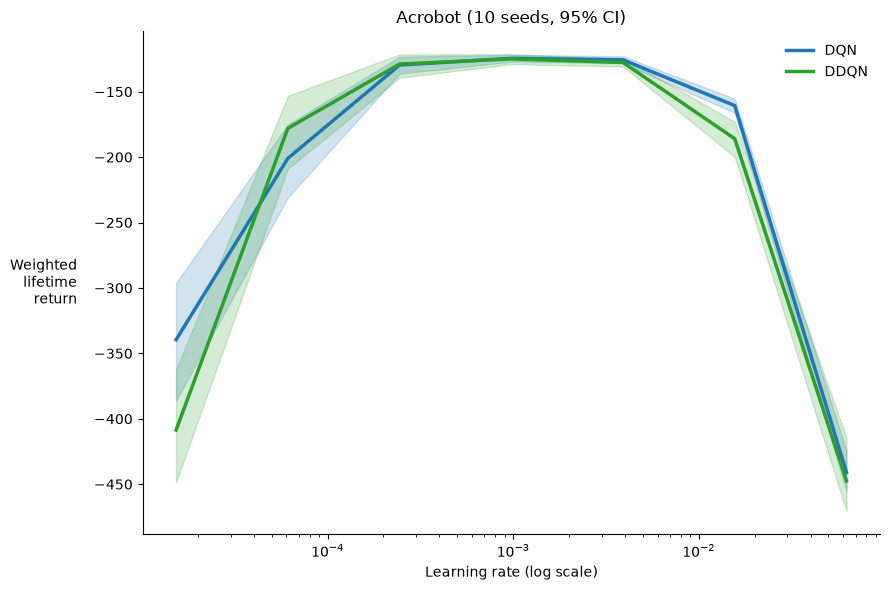

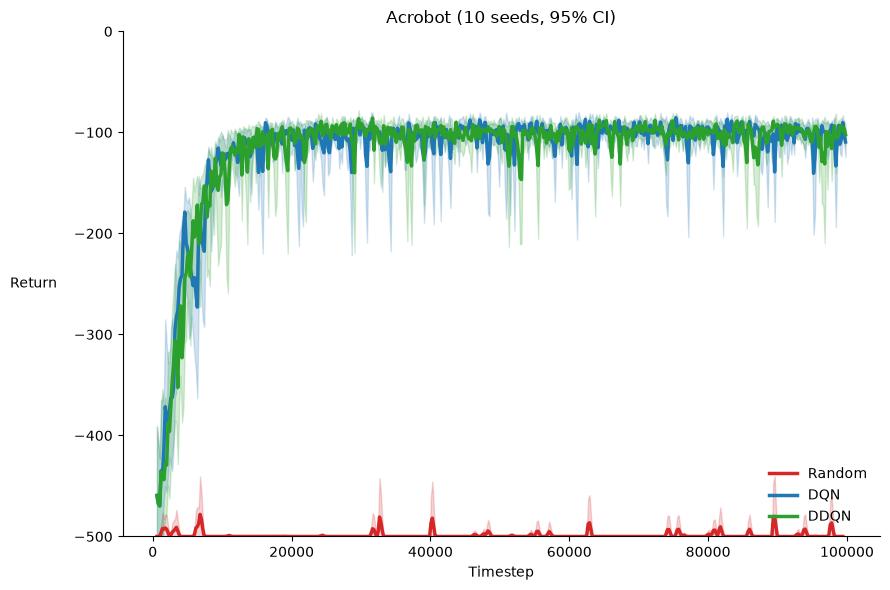

[acrobot] best LR: {'dqn': 0.0009765625, 'ddqn': 0.0009765625}


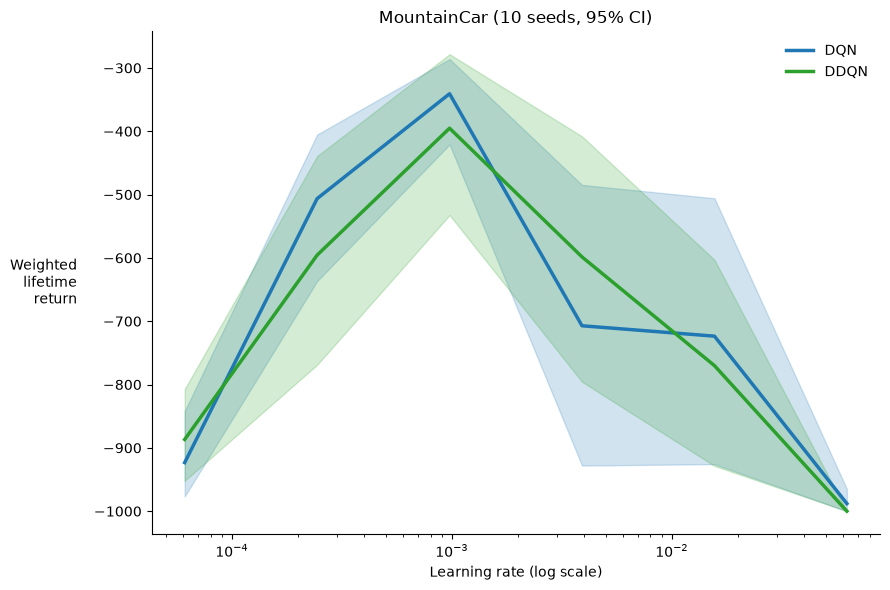

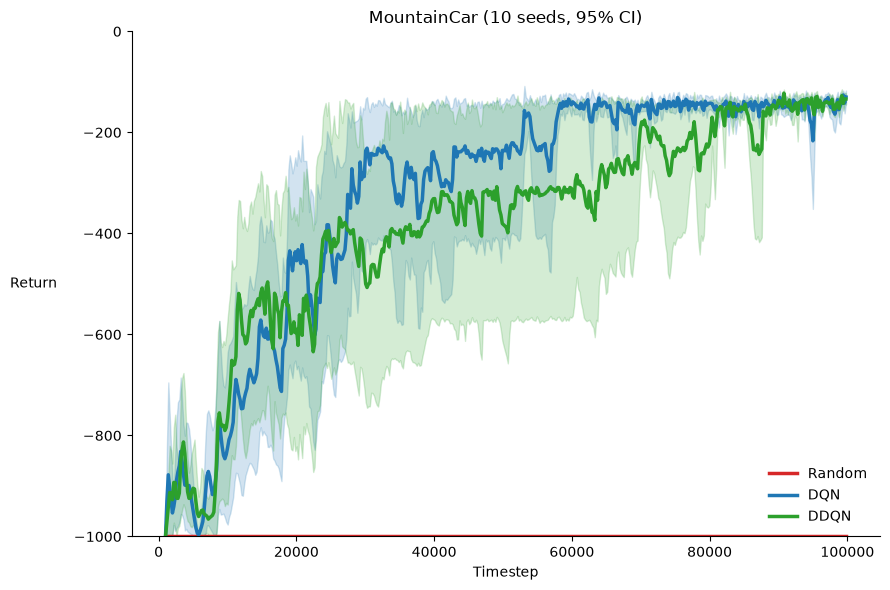

[mountaincar] best LR: {'dqn': 0.0009765625, 'ddqn': 0.0009765625}


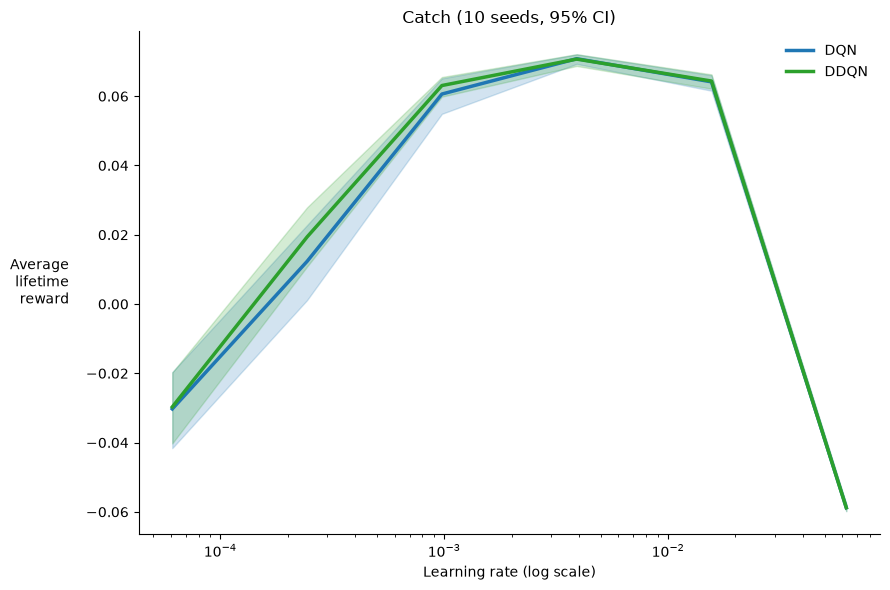

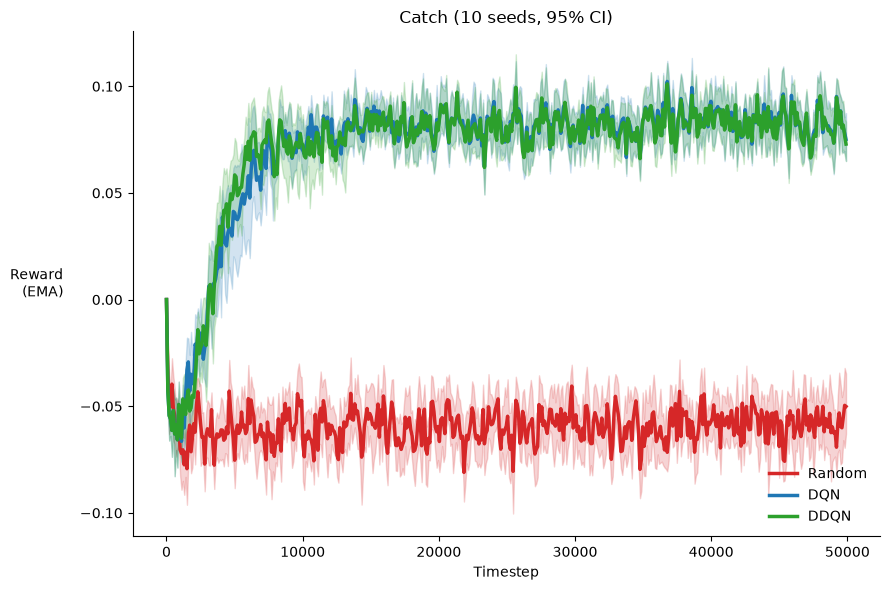

[catch] best LR: {'dqn': 0.00390625, 'ddqn': 0.00390625}


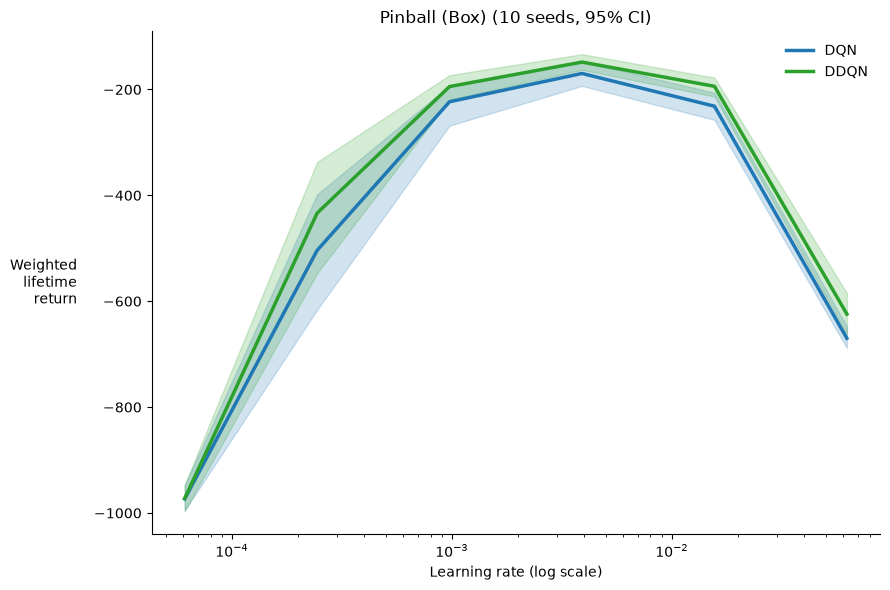

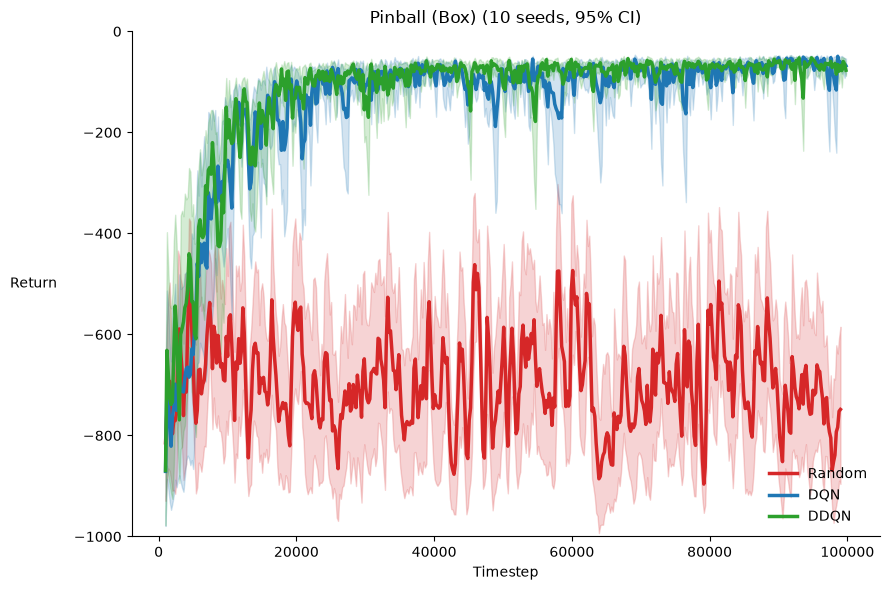

[pinball_box] best LR: {'dqn': 0.00390625, 'ddqn': 0.00390625}


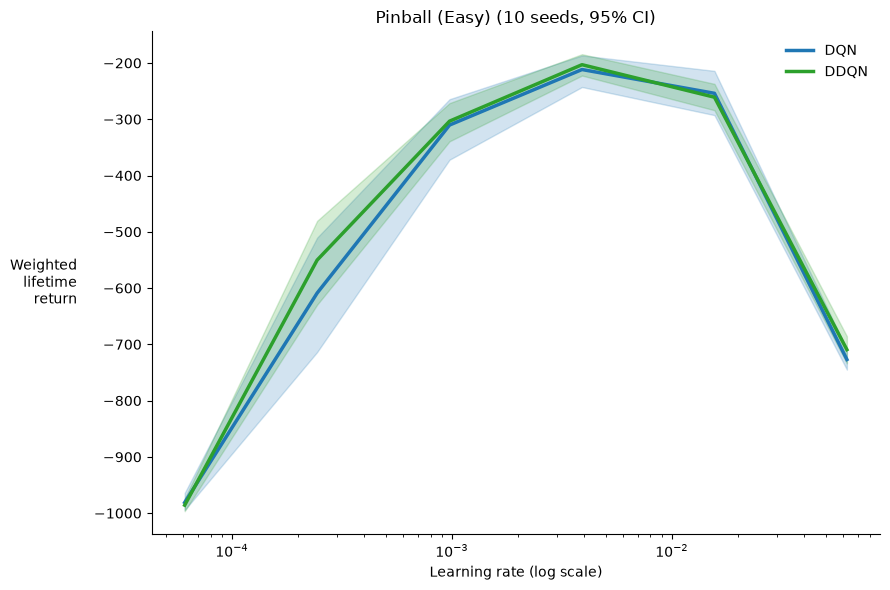

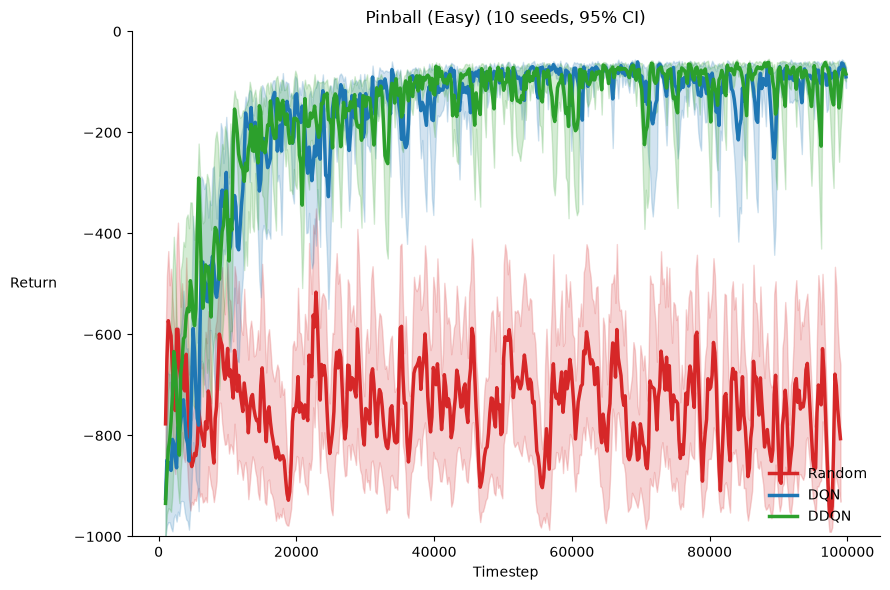

[pinball_easy] best LR: {'dqn': 0.00390625, 'ddqn': 0.00390625}


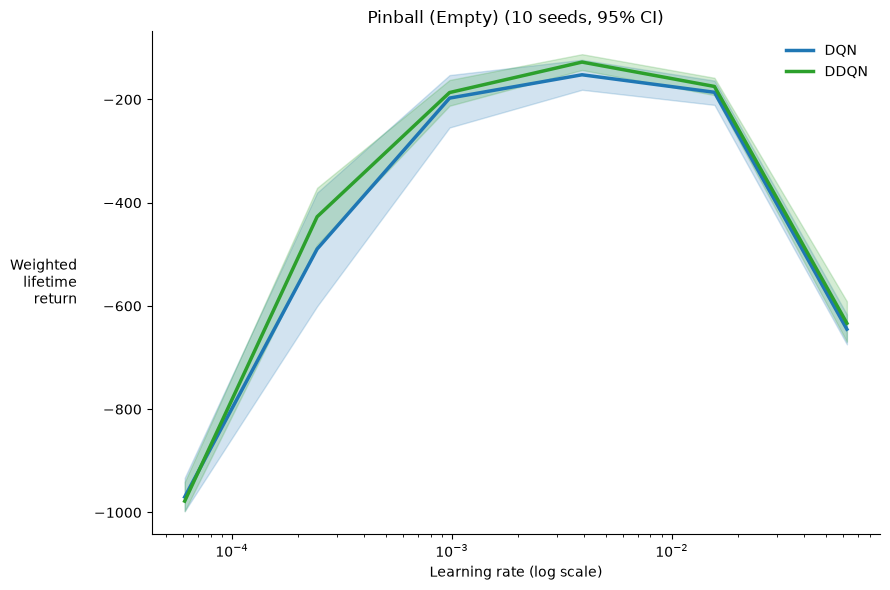

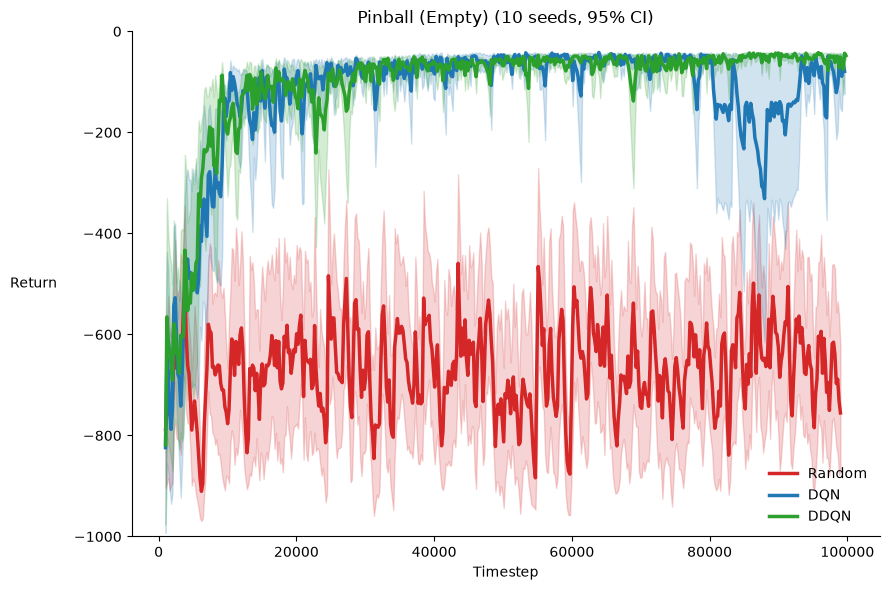

[pinball_empty] best LR: {'dqn': 0.00390625, 'ddqn': 0.00390625}


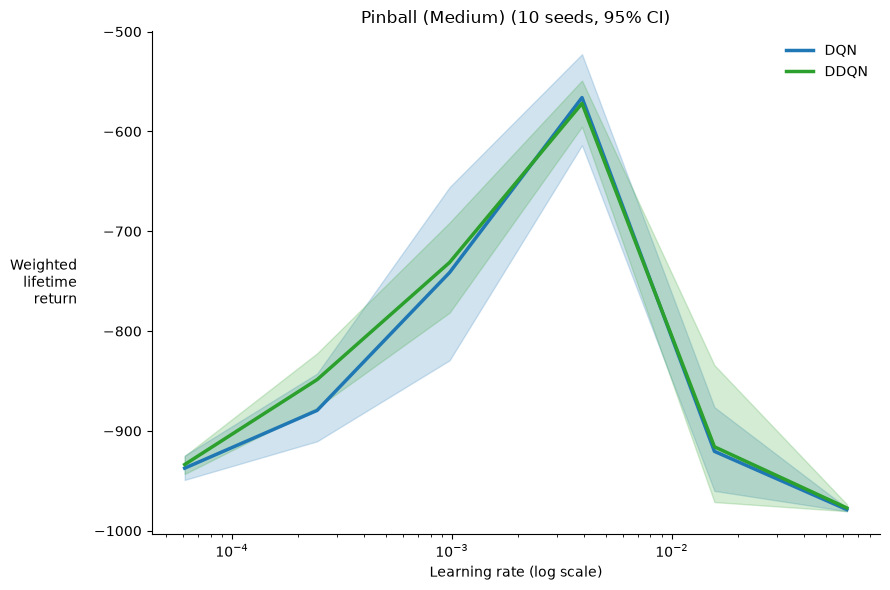

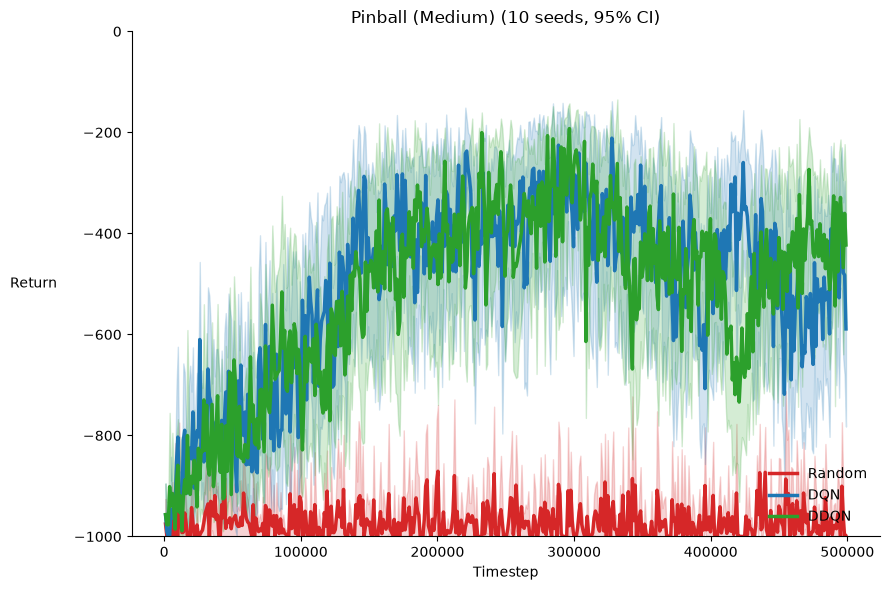

[pinball_medium] best LR: {'dqn': 0.00390625, 'ddqn': 0.00390625}

best LR by environment:
  cartpole: {'dqn': 0.000244140625, 'ddqn': 0.000244140625}
  acrobot: {'dqn': 0.0009765625, 'ddqn': 0.0009765625}
  mountaincar: {'dqn': 0.0009765625, 'ddqn': 0.0009765625}
  catch: {'dqn': 0.00390625, 'ddqn': 0.00390625}
  pinball_box: {'dqn': 0.00390625, 'ddqn': 0.00390625}
  pinball_easy: {'dqn': 0.00390625, 'ddqn': 0.00390625}
  pinball_empty: {'dqn': 0.00390625, 'ddqn': 0.00390625}
  pinball_medium: {'dqn': 0.00390625, 'ddqn': 0.00390625}

saved 16 plot(s) to /Users/parhammohammadpanahi/dev/online-gsp-tuning-experiment/experiments/tuning/plots


In [3]:
best_lrs = {env["key"]: analyze(**env) for env in ENVS}

print("\nbest LR by environment:")
for key, lrs in best_lrs.items():
    print(f"  {key}: {lrs}")
print(f"\nsaved {2 * len(ENVS)} plot(s) to {PLOTS_DIR}")